# Edinburgh Airbnb Pricing Behaviour: The 2019 Festival Fringe

**Data:** InsideAirbnb Edinburgh (scraped June 25, 2019)
**Event:** Edinburgh Festival Fringe — August 2–26, 2019
**Calendar Window:** June 25, 2019 → June 24, 2020

Every August, the Edinburgh Fringe drives a sharp and predictable increase in accommodation demand across the city.

This analysis examines how Airbnb hosts responded to that demand surge and whether pricing behavior aligned with market conditions.

The analysis focuses on five questions:

1. **Market Response:** How did Airbnb prices change during the Fringe?
2. **Flat-Pricers:** Which listings did not meaningfully increase prices despite higher demand?
3. **Drivers of Pricing Behaviour:** How do booking activity and host portfolio size relate to pricing decisions?
4. **Predictive Signals:** Which host characteristics are associated with flat-pricing behaviour?
5. **Revenue Impact:** What revenue opportunity may be missed by hosts who do not adjust prices during the festival?


### Key Definitions

| Term | Definition | Criteria / Calculation |
|---|---|---|
| **Price Index** | Listing day price relative to its normal off-season pricing level. | `day_price / baseline_median_price` |
| **Baseline Median Price** | Median listing price during lower-demand reference windows outside the Fringe period. Calculated only on available days. | — |
| **Flat-Pricer** | Listing whose median Fringe price remains close to baseline levels. | `median_fringe_price_index < 1.10` |
| **Host Tier** | Portfolio scale based on total listings managed by a host. | `1`, `2–5`, or `6+` listings |
| **Booking Volume Tier** | Transaction frequency based on trailing 12-month review volume. | Quartile split of `recent_review_count` |
| **Revenue Gap** | Difference between observed prices and prices implied by the market median Fringe markup. Calculated only on successfully booked days. | `potential_price − observed_price` |

In [1]:
# ── 1. SETUP ──────────────────────────────────────────────────

from pathlib import Path

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)

# Data location
DATA_PATH = Path('../data')

# Analysis parameters
FRINGE_START = pd.Timestamp('2019-08-02')
FRINGE_END = pd.Timestamp('2019-08-26')
SCRAPE_DATE = pd.Timestamp('2019-06-25')

BASELINE_WINDOWS = [
    ('2019-10-01', '2019-11-20'),
    ('2020-01-10', '2020-02-20')
]

FLAT_PRICER_THRESHOLD = 1.10

# Category ordering for plots

VOLUME_ORDER = [
    'low_volume',
    'mid_volume',
    'high_volume'
]

TIME_ORDER = [
    'within_an_hour',
    'within_a_few_hours',
    'within_a_day',
    'a_few_days_or_more'
]

# Plot styling
PRIMARY = '#4C72B0'
ACCENT = '#DD8452'

sns.set_style('whitegrid')

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa',
    'axes.grid': True,
    'grid.color': 'white',
    'grid.linewidth': 1.2,
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.labelsize': 11
})

print('Setup complete')

Setup complete


## 2. Data Loading & Variable Construction

The analysis combines three InsideAirbnb datasets:

- **Listings:** Property and host attributes.
- **Calendar:** Daily prices and availability over the following 12 months.
- **Reviews:** Used to estimate booking activity.

### Key Variables

**Booking Volume Tier**

Booking activity is approximated using the number of reviews received in the 12 months prior to the scrape date.

- `low_volume`: ≤ 25th percentile
- `mid_volume`: 25th–75th percentile
- `high_volume`: ≥ 75th percentile

**Price Index**

`price_index = day_price / baseline_median_price`

This metric measures each listing's daily price relative to its typical off-season rate.

The baseline median price is calculated using two off-season periods:

- Oct 1 – Nov 20, 2019
- Jan 10 – Feb 20, 2020

Only listings with at least 10 available baseline days are included in the indexed pricing analysis.

In [3]:
# ── 2. DATA LOADING & LISTINGS CLEANING ───────────────────────

# Load datasets
DATA_PATH = Path('./data')
listings_raw = pd.read_csv(
    DATA_PATH / 'listings.csv',
    engine='python',
    encoding='utf-8',
    on_bad_lines='skip'
)

# Load reviews.csv
reviews_raw = pd.read_csv(
    DATA_PATH / 'reviews.csv',
    engine='python',
    encoding='utf-8',
    on_bad_lines='skip'
)

# Load calendar.csv
calendar_raw = pd.read_csv(
    DATA_PATH / 'calendar.csv',
    engine='python',
    encoding='utf-8',
    on_bad_lines='skip'
)

# Columns used in analysis
key_cols = [
    'id',
    'host_id',
    'host_since',
    'host_response_time',
    'neighbourhood_cleansed',
    'room_type',
    'price',
    'calculated_host_listings_count',
    'review_scores_rating',
    'review_scores_value'
]

listings = listings_raw[
    [c for c in key_cols if c in listings_raw.columns]
].copy()

# Basic type cleaning
listings['price'] = (
    listings['price']
    .astype(str)
    .str.replace(r'[$£,]', '', regex=True)
    .astype(float)
)

listings['host_since'] = pd.to_datetime(
    listings['host_since'],
    errors='coerce'
)

# Calendar cleaning
calendar = calendar_raw.copy()

calendar['date'] = pd.to_datetime(calendar['date'])
calendar['is_available'] = calendar['available'].eq('t')

calendar['day_price'] = (
    calendar['price']
    .astype(str)
    .str.replace(r'[$£,]', '', regex=True)
    .astype(float)
)

# Keep only listings included in analysis
calendar = calendar[
    calendar['listing_id'].isin(listings['id'])
].copy()

# Host response time formatting
if 'host_response_time' in listings.columns:
    listings['host_response_time'] = (
        listings['host_response_time']
        .str.replace(' ', '_')
    )

# Remove extreme price outliers
listings = listings[
    listings['price'].between(10, 1000)
].copy()

# Host portfolio size tiers
listings['host_tier'] = listings[
    'calculated_host_listings_count'
].apply(
    lambda n:
        'single_property' if n == 1
        else 'small_portfolio' if n <= 5
        else 'large_portfolio'
)

# Review activity during the year before scrape date
reviews_raw['date'] = pd.to_datetime(
    reviews_raw['date'],
    errors='coerce'
)

activity = (
    reviews_raw[
        (reviews_raw['date'] >= SCRAPE_DATE - pd.DateOffset(months=12))
        & (reviews_raw['date'] <= SCRAPE_DATE)
    ]
    .groupby('listing_id')
    .size()
    .reset_index(name='recent_review_count')
)

listings = listings.merge(
    activity,
    left_on='id',
    right_on='listing_id',
    how='left'
)

listings['recent_review_count'] = (
    listings['recent_review_count']
    .fillna(0)
    .astype(int)
)

listings.drop(
    columns=['listing_id'],
    inplace=True,
    errors='ignore'
)

# Booking volume tiers
q25 = listings['recent_review_count'].quantile(0.25)
q75 = listings['recent_review_count'].quantile(0.75)

listings['booking_volume_tier'] = listings[
    'recent_review_count'
].apply(
    lambda n:
        'low_volume' if n <= q25
        else 'high_volume' if n >= q75
        else 'mid_volume'
)

print(f'Listings after cleaning: {len(listings):,}')
print(f'Calendar rows retained: {len(calendar):,}')

Listings after cleaning: 13,191
Calendar rows retained: 4,834,568


## 3. Calendar & Price Index

Comparing absolute prices is not very informative because listings vary widely in size, location, and property type. Instead, pricing is evaluated relative to each listing's typical off-season rate.

`price_index = fringe_day_price / baseline_median_price`

A valid baseline requires sufficient off-season observations. Listings with fewer than 10 available days across the reference periods are excluded from the indexed pricing analysis.

In [4]:
# ── 3. PRICE INDEX ─────────────────────────────────



def classify_date(date):
    if FRINGE_START <= date <= FRINGE_END:
        return 'fringe'
    for start, end in BASELINE_WINDOWS:
        if pd.Timestamp(start) <= date <= pd.Timestamp(end):
            return 'baseline'
    return 'other'

calendar['window'] = calendar['date'].apply(classify_date)

# Baseline pricing during reference periods
baseline_stats = (
    calendar[
        (calendar['window'] == 'baseline') &
        calendar['is_available'] &
        calendar['day_price'].notna() &
        (calendar['day_price'] > 0)
    ]
    .groupby('listing_id')
    .agg(
        baseline_median_price=('day_price', 'median'),
        baseline_days=('day_price', 'count')
    )
    .reset_index()
)

# Require at least 10 baseline days
baseline_stats = baseline_stats[baseline_stats['baseline_days'] >= 10]

calendar = calendar.merge(
    baseline_stats[['listing_id', 'baseline_median_price']],
    on='listing_id',
    how='left'
)

# Calculate price index
calendar['price_index'] = (
    calendar['day_price'] / calendar['baseline_median_price']
)

# Listing attributes used in later analysis
merge_cols = [
    'id',
    'host_tier',
    'booking_volume_tier',
    'room_type',
    'neighbourhood_cleansed',
    'host_response_time',
    'host_since',
    'review_scores_rating',
    'review_scores_value'
]

# Keep available columns only
merge_cols = [col for col in merge_cols if col in listings.columns]

master = calendar.merge(
    listings[merge_cols],
    left_on='listing_id',
    right_on='id',
    how='inner'
)

master.drop(columns=['id'], inplace=True)

print(
    f'Master calendar: {len(master):,} rows · '
    f'{master["listing_id"].nunique():,} listings'
)

print(f'Listings with valid price_index: {len(baseline_stats):,}')

Master calendar: 4,814,856 rows · 13,191 listings
Listings with valid price_index: 5,705


---
## 4. Market-Wide Response to the Fringe

Before segmenting host behaviour, we must verify that the Edinburgh Fringe creates a measurable, market-wide pricing response.

To do this, we track the weekly median `price_index` across the full calendar year. Because the price index normalizes each listing relative to its own baseline price, a rise above `1.0` indicates that the market as a whole is successfully charging a premium over typical off-season rates.

In [ ]:
# ── 4. MARKET-WIDE RESPONSE ───────────────────────────────────

weekly = (
    master[
        master['is_available'] &
        master['price_index'].notna() &
        (master['price_index'] > 0)
    ]
    .assign(
        week=lambda df: df['date']
        .dt.to_period('W')
        .apply(lambda r: r.start_time)
    )
    .groupby('week')
    .agg(median_price_index=('price_index', 'median'))
    .reset_index()
)

fig, ax = plt.subplots(figsize=(16, 6))

ax.plot(
    weekly['week'],
    weekly['median_price_index'],
    color=PRIMARY,
    linewidth=2,
    zorder=3
)

ax.axvspan(
    FRINGE_START,
    FRINGE_END,
    alpha=0.15,
    color=ACCENT,
    label='Edinburgh Fringe (Aug 2–26)',
    zorder=2
)

ax.axhline(
    1.0,
    color='#555',
    linewidth=1,
    linestyle='--',
    alpha=0.6,
    label='Baseline (1.0×)'
)

peak_week = weekly.loc[weekly['median_price_index'].idxmax()]

ax.annotate(
    f'Peak: {peak_week["median_price_index"]:.2f}×\n'
    f'(week of {peak_week["week"].strftime("%b %d")})',
    xy=(peak_week['week'], peak_week['median_price_index']),
    xytext=(
        pd.Timestamp('2019-10-01'),
        peak_week['median_price_index'] * 0.92
    ),
    fontsize=10,
    fontweight='bold',
    color=ACCENT,
    arrowprops=dict(
        arrowstyle='->',
        color=ACCENT,
        lw=1.5
    )
)

ax.set_title(
    'Market-Wide Price Response During the Edinburgh Fringe\n'
    'Weekly Median Price Index Across All Listings',
    fontsize=13,
    fontweight='bold',
    pad=12
)

ax.set_ylabel('Price Index (1.0 = Baseline)')
ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.1f×'))

ax.set_xlim(weekly['week'].min(), weekly['week'].max())
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

print(
    f'Peak Fringe-week median price index: '
    f'{peak_week["median_price_index"]:.2f}×'
)

**Key Takeaway:** The median price index peaks at **1.78×** during the Fringe and remains close to baseline for most of the year. This suggests the festival creates a clear and concentrated pricing response across the market.

The next section examines how individual listings differed in their response to this demand surge.

## 5. Flat-Pricer Identification

A **flat-pricer** is defined as a listing with a median Fringe `price_index` below **1.10×**. In other words, the listing's median Fringe price remained within 10% of its typical off-season rate.

This section identifies flat-pricers and compares their prevalence across host portfolio sizes and booking volume tiers.

In [ ]:
# ── 5.1 FRINGE LISTING SUMMARY ────────────────────────────────

fringe_peak_data = master[
    (master['window'] == 'fringe') &
    master['price_index'].notna()
].copy()

fringe_listings = (
    fringe_peak_data
    .groupby('listing_id')
    .agg(
        median_fringe_price_index=('price_index', 'median'),
        available_fraction=('is_available', 'mean'),
        host_tier=('host_tier', 'first'),
        booking_volume_tier=('booking_volume_tier', 'first'),
        room_type=('room_type', 'first'),
        neighbourhood_cleansed=('neighbourhood_cleansed', 'first'),
        host_response_time=('host_response_time', 'first'),
        host_since=('host_since', 'first'),
        baseline_median_price=('baseline_median_price', 'first')
    )
    .reset_index()
)

fringe_listings['is_flat_pricer'] = (
    fringe_listings['median_fringe_price_index'] < FLAT_PRICER_THRESHOLD
)

print(
    f"Listings active during Fringe with valid price_index: "
    f"{len(fringe_listings):,}"
)

print(
    f"Overall market flat-pricer rate: "
    f"{fringe_listings['is_flat_pricer'].mean():.1%}"
)

Listings active during Fringe with valid price_index: 5,689
Overall market flat-pricer rate: 25.1%


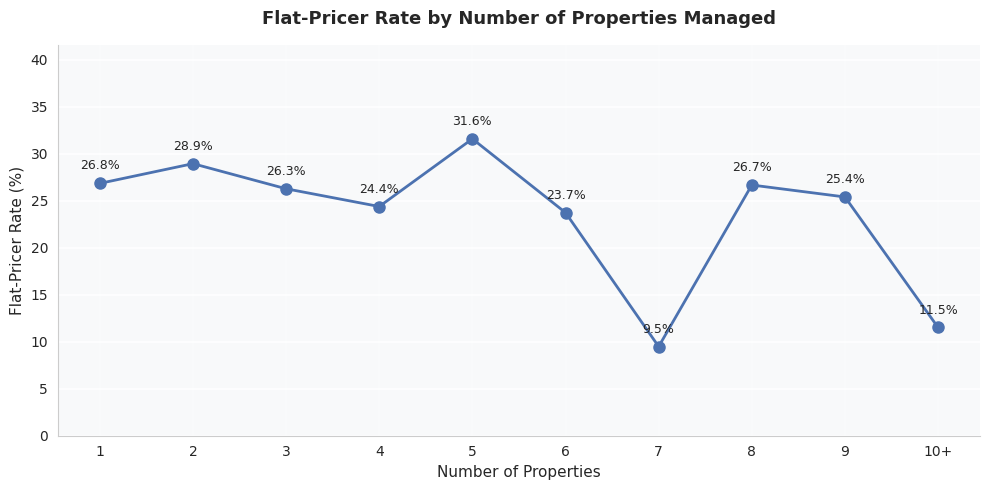

In [ ]:
# ── 5.2 FLAT-PRICER RATE BY PORTFOLIO SIZE ────────────────────

# Exact property counts for each listing
exact_counts = (
    listings[['id', 'calculated_host_listings_count']]
    .drop_duplicates()
    .rename(columns={'id': 'listing_id'})
)

fringe_with_counts = fringe_listings.merge(
    exact_counts,
    on='listing_id',
    how='left'
)

# Cap at 10+ for display purposes
fringe_with_counts['capped_count'] = (
    fringe_with_counts['calculated_host_listings_count']
    .clip(upper=10)
)

rate_by_count = (
    fringe_with_counts
    .groupby('capped_count')
    .agg(
        flat_rate=('is_flat_pricer', 'mean'),
        listing_count=('is_flat_pricer', 'count')
    )
)

rate_by_count['flat_rate'] = rate_by_count['flat_rate'] * 100

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    rate_by_count.index,
    rate_by_count['flat_rate'],
    marker='o',
    color=PRIMARY,
    linewidth=2,
    markersize=8
)

# Data labels
for count, rate in zip(rate_by_count.index, rate_by_count['flat_rate']):
    ax.annotate(
        f"{rate:.1f}%",
        xy=(count, rate),
        xytext=(0, 10),
        textcoords="offset points",
        ha='center',
        fontsize=9
    )

ax.set_title(
    'Flat-Pricer Rate by Number of Properties Managed',
    fontweight='bold',
    pad=15
)

ax.set_xlabel('Number of Properties')
ax.set_ylabel('Flat-Pricer Rate (%)')
ax.set_xticks(range(1, 11))
ax.set_xticklabels([str(i) for i in range(1, 10)] + ['10+'])
ax.set_ylim(0, rate_by_count['flat_rate'].max() + 10)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

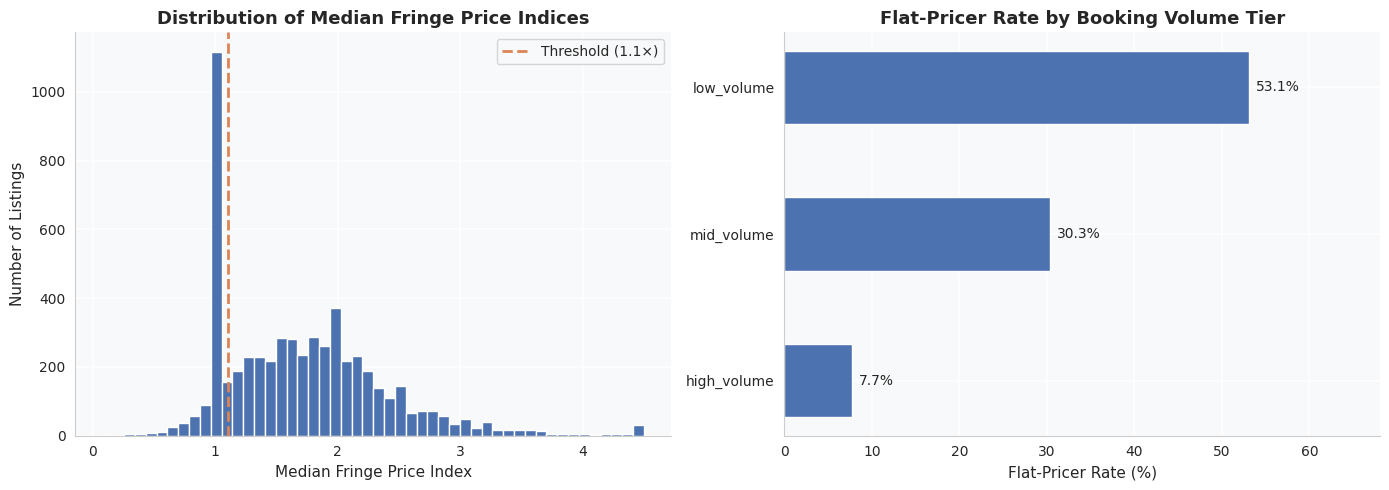

In [ ]:
# ── 5.3 FLAT-PRICER DISTRIBUTIONS ─────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution of Fringe price indices
ax = axes[0]

ax.hist(
    fringe_listings['median_fringe_price_index'].clip(upper=4.5),
    bins=50,
    color=PRIMARY,
    edgecolor='white'
)

ax.axvline(
    FLAT_PRICER_THRESHOLD,
    color=ACCENT,
    linestyle='--',
    linewidth=2,
    label=f'Threshold ({FLAT_PRICER_THRESHOLD}×)'
)

ax.set_title(
    'Distribution of Median Fringe Price Indices',
    fontweight='bold'
)

ax.set_xlabel('Median Fringe Price Index')
ax.set_ylabel('Number of Listings')
ax.legend()

# Flat-pricer rates by booking volume
ax = axes[1]

rates = (
    fringe_listings
    .groupby('booking_volume_tier', observed=True)['is_flat_pricer']
    .mean()
    .reindex(VOLUME_ORDER) * 100
)

bars = ax.barh(
    rates.index,
    rates.values,
    color=PRIMARY,
    height=0.5
)

ax.bar_label(bars, fmt='%.1f%%', padding=5)

ax.set_title(
    'Flat-Pricer Rate by Booking Volume Tier',
    fontweight='bold'
)

ax.set_xlabel('Flat-Pricer Rate (%)')
ax.set_xlim(0, rates.max() + 15)
ax.invert_yaxis()

plt.tight_layout()
plt.show()

## 6. Controlled Comparisons: Geography & Room Type

Booking volume appears to be associated with flat-pricing, but this relationship could be influenced by differences in property type or location.

To check whether the pattern holds across different market segments, flat-pricer rates are compared across booking volume tiers within room types and the city's largest neighbourhoods.

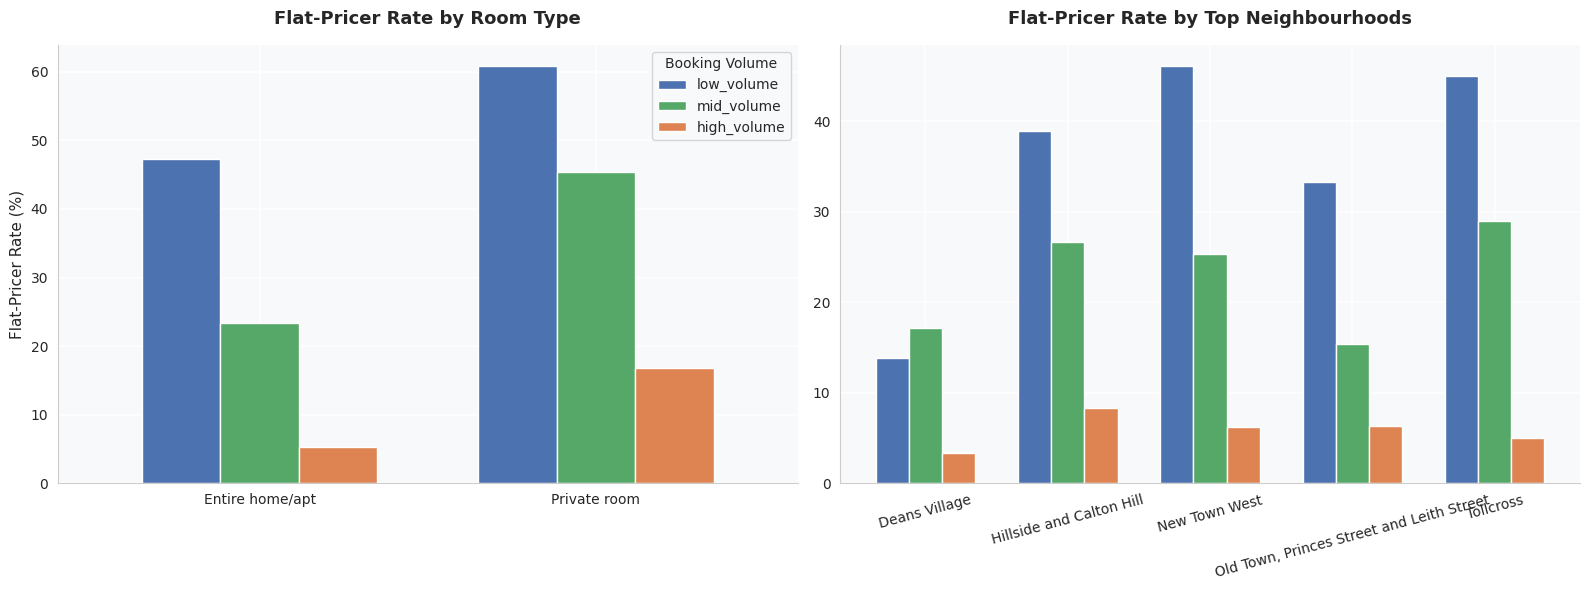

In [ ]:
# ── 6. CONTROLLED COMPARISONS: GEOGRAPHY & ROOM TYPE ──────────

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Consistent colors across booking volume tiers
VOLUME_COLORS = ['#4C72B0', '#55A868', '#DD8452']

# Room type comparison
ax1 = axes[0]

room_rates = (
    fringe_listings[
        fringe_listings['room_type'].isin(['Entire home/apt', 'Private room'])
    ]
    .groupby(['room_type', 'booking_volume_tier'], observed=True)['is_flat_pricer']
    .mean()
    .unstack()
    .reindex(columns=VOLUME_ORDER) * 100
)

room_rates.plot(
    kind='bar',
    ax=ax1,
    color=VOLUME_COLORS,
    edgecolor='white',
    width=0.7
)

ax1.set_title('Flat-Pricer Rate by Room Type', fontweight='bold', pad=15)
ax1.set_ylabel('Flat-Pricer Rate (%)')
ax1.set_xlabel('')
ax1.tick_params(axis='x', rotation=0)
ax1.legend(title='Booking Volume', loc='upper right')

# Neighbourhood comparison
ax2 = axes[1]

top_neighborhoods = (
    fringe_listings['neighbourhood_cleansed']
    .value_counts()
    .head(5)
    .index
)

neighborhood_rates = (
    fringe_listings[
        fringe_listings['neighbourhood_cleansed'].isin(top_neighborhoods)
    ]
    .groupby(
        ['neighbourhood_cleansed', 'booking_volume_tier'],
        observed=True
    )['is_flat_pricer']
    .mean()
    .unstack()
    .reindex(columns=VOLUME_ORDER) * 100
)

neighborhood_rates.plot(
    kind='bar',
    ax=ax2,
    color=VOLUME_COLORS,
    edgecolor='white',
    width=0.7
)

ax2.set_title(
    'Flat-Pricer Rate by Top Neighbourhoods',
    fontweight='bold',
    pad=15
)

ax2.set_ylabel('')
ax2.set_xlabel('')
ax2.tick_params(axis='x', rotation=15)

# Remove duplicate legend
ax2.legend().remove()

plt.tight_layout()
plt.show()

In [ ]:
# ── 6.1 CONTEXT: PRICING & SAMPLE SIZES ───────────────────────

# Top five neighbourhoods by listing count
top_neighborhoods = (
    fringe_listings['neighbourhood_cleansed']
    .value_counts()
    .head(5)
    .index
)

print("=== MEDIAN OFF-SEASON BASE PRICE ===")

room_prices = (
    fringe_listings[
        fringe_listings['room_type'].isin(['Entire home/apt', 'Private room'])
    ]
    .groupby('room_type')['baseline_median_price']
    .median()
)

for room, price in room_prices.items():
    print(f"{room:42s} £{price:.0f} / night")

neighborhood_prices = (
    fringe_listings[
        fringe_listings['neighbourhood_cleansed'].isin(top_neighborhoods)
    ]
    .groupby('neighbourhood_cleansed')['baseline_median_price']
    .median()
    .sort_values(ascending=False)
)

for nbhd, price in neighborhood_prices.items():
    print(f"{nbhd:42s} £{price:.0f} / night")

print('\n=== SAMPLE SIZES: ROOM TYPE × VOLUME TIER ===')

display(
    fringe_listings[
        fringe_listings['room_type'].isin(['Entire home/apt', 'Private room'])
    ]
    .groupby(['room_type', 'booking_volume_tier'])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=VOLUME_ORDER)
)

print('\n=== SAMPLE SIZES: NEIGHBOURHOOD × VOLUME TIER ===')

display(
    fringe_listings[
        fringe_listings['neighbourhood_cleansed'].isin(top_neighborhoods)
    ]
    .groupby(['neighbourhood_cleansed', 'booking_volume_tier'])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=VOLUME_ORDER)
)

=== MEDIAN OFF-SEASON BASE PRICE ===
Entire home/apt                            £95 / night
Private room                               £45 / night
New Town West                              £118 / night
Deans Village                              £101 / night
Old Town, Princes Street and Leith Street  £101 / night
Tollcross                                  £92 / night
Hillside and Calton Hill                   £84 / night

=== SAMPLE SIZES: ROOM TYPE × VOLUME TIER ===


booking_volume_tier,low_volume,mid_volume,high_volume
room_type,,,
Entire home/apt,488,1689,1769
Private room,409,825,462



=== SAMPLE SIZES: NEIGHBOURHOOD × VOLUME TIER ===


booking_volume_tier,low_volume,mid_volume,high_volume
neighbourhood_cleansed,,,
Deans Village,65,140,118
Hillside and Calton Hill,18,60,108
New Town West,26,79,81
"Old Town, Princes Street and Leith Street",81,214,334
Tollcross,40,114,158


## 7. Host Experience & Flat-Pricing

One possible explanation for pricing differences is host experience. Hosts who have been through multiple Fringe seasons may respond differently to festival demand than newer hosts.

This section compares flat-pricing rates by the number of prior Fringe festivals each host has experienced.

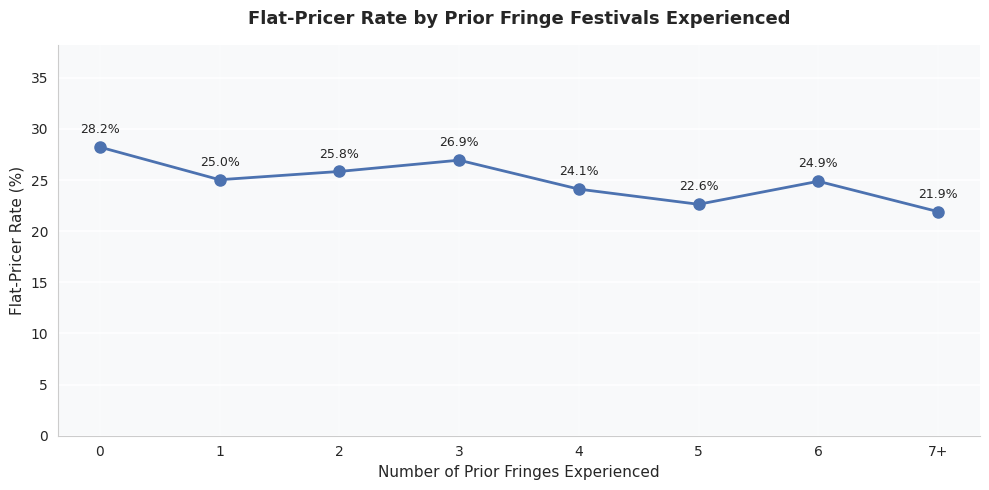

In [ ]:
# ── 7. HOST EXPERIENCE ────────────────────────────────────────

# Estimate the number of Fringe festivals experienced before 2019
fringe_experience = fringe_listings.copy()

fringe_experience['years_hosting'] = (
    (FRINGE_START - fringe_experience['host_since']).dt.days / 365.25
)

fringe_experience['prior_fringes'] = fringe_experience['years_hosting'].apply(
    lambda x: int(x) if pd.notna(x) and x > 0 else 0
)

# Group 7 or more prior Fringes together
fringe_experience['capped_fringes'] = (
    fringe_experience['prior_fringes'].clip(upper=7)
)

experience_rates = (
    fringe_experience
    .groupby('capped_fringes')
    .agg(
        flat_rate=('is_flat_pricer', 'mean'),
        count=('is_flat_pricer', 'count')
    )
)

experience_rates['flat_rate'] = experience_rates['flat_rate'] * 100

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    experience_rates.index,
    experience_rates['flat_rate'],
    marker='o',
    color=PRIMARY,
    linewidth=2,
    markersize=8
)

# Data labels
for count, rate in zip(
    experience_rates.index,
    experience_rates['flat_rate']
):
    ax.annotate(
        f"{rate:.1f}%",
        xy=(count, rate),
        xytext=(0, 10),
        textcoords="offset points",
        ha='center',
        fontsize=9
    )

ax.set_title(
    'Flat-Pricer Rate by Prior Fringe Festivals Experienced',
    fontweight='bold',
    pad=15
)

ax.set_xlabel('Number of Prior Fringes Experienced')
ax.set_ylabel('Flat-Pricer Rate (%)')
ax.set_xticks(range(8))
ax.set_xticklabels([str(i) for i in range(7)] + ['7+'])
ax.set_ylim(0, experience_rates['flat_rate'].max() + 10)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

**Key Takeaway:** Flat-pricer rates vary only modestly across experience levels. Hosts with 7+ prior Fringe festivals have a flat-pricer rate of **21.9%**, compared with **28.2%** for hosts experiencing their first Fringe.

This suggests that host tenure alone is not strongly associated with pricing behaviour during the festival period.

## 8. Predictive Signals: Weekend Pricing

One possible indicator of pricing behaviour is whether a host adjusts prices between weekdays and weekends during the off-season.

Hosts who keep similar prices throughout the week may also be less likely to adjust prices during high-demand events such as the Fringe.

A host is classified as an off-season **weekend flat-pricer** if their median weekend price is less than **1.05×** their median weekday price.

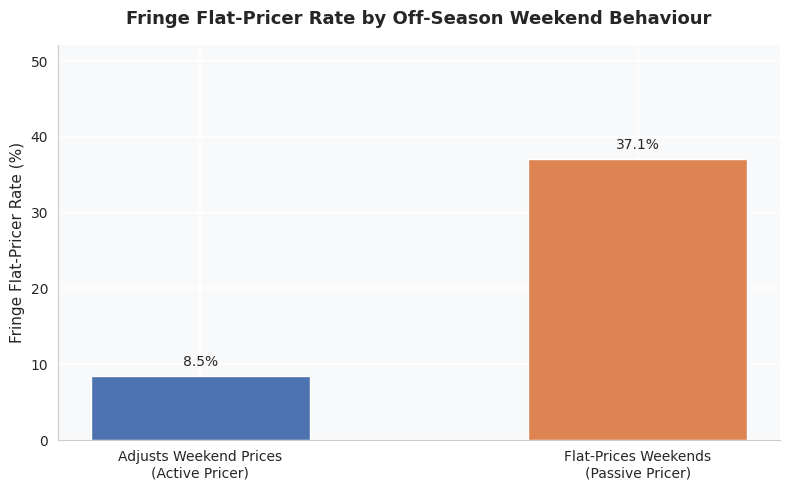

In [ ]:
# ── 8. WEEKEND PRICING SIGNAL ─────────────────────────────────

# Off-season pricing data
baseline_data = master[
    (master['window'] == 'baseline') &
    master['is_available'] &
    master['day_price'].notna() &
    (master['day_price'] > 0)
].copy()

# Weekend vs weekday pricing
baseline_data['day_of_week'] = baseline_data['date'].dt.dayofweek
baseline_data['is_weekend'] = baseline_data['day_of_week'].isin([4, 5])

weekend_calc = (
    baseline_data
    .groupby(['listing_id', 'is_weekend'])['day_price']
    .median()
    .unstack()
    .rename(columns={False: 'weekday_price', True: 'weekend_price'})
    .dropna()
)

# Weekend markup ratio
weekend_calc['weekend_ratio'] = (
    weekend_calc['weekend_price'] /
    weekend_calc['weekday_price']
)

# Weekend flat-pricers (<5% weekend premium)
weekend_calc['is_weekend_flat'] = weekend_calc['weekend_ratio'] < 1.05

# Merge with Fringe pricing outcomes
fringe_with_weekend = fringe_listings.merge(
    weekend_calc[['is_weekend_flat']],
    on='listing_id',
    how='inner'
)

# Fringe flat-pricer rates by weekend pricing behaviour
weekend_rates = (
    fringe_with_weekend
    .groupby('is_weekend_flat')['is_flat_pricer']
    .mean() * 100
)

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    [
        'Adjusts Weekend Prices\n(Active Pricer)',
        'Flat-Prices Weekends\n(Passive Pricer)'
    ],
    weekend_rates.values,
    color=[PRIMARY, ACCENT],
    width=0.5
)

ax.bar_label(bars, fmt='%.1f%%', padding=5)

ax.set_title(
    'Fringe Flat-Pricer Rate by Off-Season Weekend Behaviour',
    fontweight='bold',
    pad=15
)

ax.set_ylabel('Fringe Flat-Pricer Rate (%)')
ax.set_ylim(0, weekend_rates.max() + 15)

plt.tight_layout()
plt.show()

# Store for later modeling
weekend_price_calc = weekend_calc.copy()

**Key Takeaway:** Weekend pricing behaviour is strongly associated with Fringe pricing behaviour. Hosts who flat-price weekends have a flat-pricer rate of **37.1%**, compared with **8.5%** for hosts who apply a weekend premium.

This suggests that routine pricing habits may be a useful indicator of how hosts respond to larger demand shifts.

## 9. Demand Curve & Revenue Efficiency

Higher prices do not necessarily lead to higher revenue if they result in lower occupancy. This section examines the relationship between pricing and availability during the peak Fringe weekend (August 9–11).

The goal is to assess whether lower-priced listings appear to compensate through higher occupancy during the period of strongest demand.

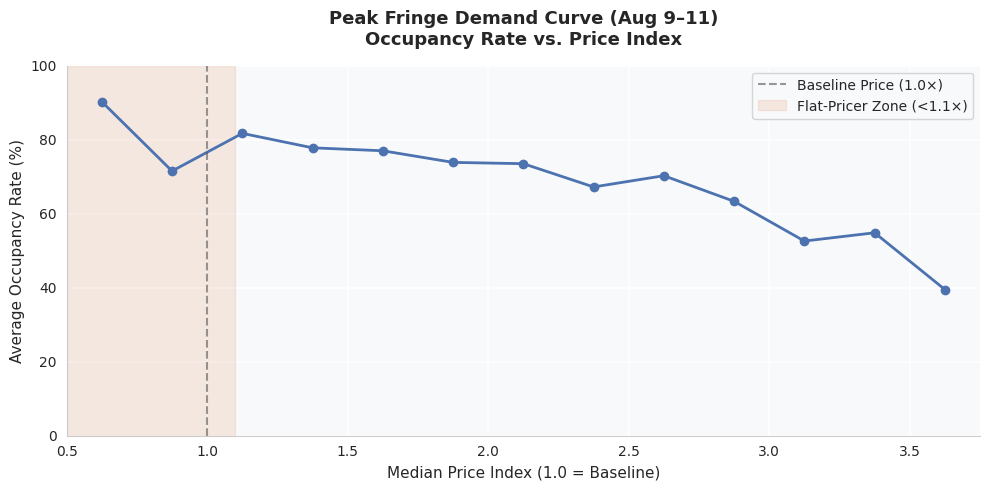

Flat-Pricer Average Occupancy: 74.0%
Market-Rate Pricer (1.5x+) Average Occupancy: 68.9%


In [ ]:
# ── 9. DEMAND CURVE & REVENUE EFFICIENCY ──────────────────────

# Peak Fringe weekend
peak_fringe_dates = master[
    (master['date'] >= '2019-08-09') &
    (master['date'] <= '2019-08-11')
].copy()

# Occupancy and pricing during the peak weekend
demand_curve = (
    peak_fringe_dates
    .groupby('listing_id')
    .agg(
        occupancy_rate=('is_available', lambda x: 1 - x.mean()),
        median_price_index=('price_index', 'median')
    )
    .dropna()
)

# Price index bins
demand_curve['price_bin'] = pd.cut(
    demand_curve['median_price_index'],
    bins=np.arange(0.5, 4.0, 0.25)
)

occupancy_by_price = (
    demand_curve
    .groupby('price_bin', observed=True)['occupancy_rate']
    .mean() * 100
)

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    [bin.mid for bin in occupancy_by_price.index],
    occupancy_by_price.values,
    marker='o',
    color=PRIMARY,
    linewidth=2
)

ax.axvline(
    1.0,
    color='#555',
    linestyle='--',
    alpha=0.6,
    label='Baseline Price (1.0×)'
)

ax.axvspan(
    0.5,
    FLAT_PRICER_THRESHOLD,
    alpha=0.15,
    color=ACCENT,
    label=f'Flat-Pricer Zone (<{FLAT_PRICER_THRESHOLD}×)'
)

ax.set_title(
    'Peak Fringe Demand Curve (Aug 9–11)\nOccupancy Rate vs. Price Index',
    fontweight='bold',
    pad=15
)

ax.set_xlabel('Median Price Index (1.0 = Baseline)')
ax.set_ylabel('Average Occupancy Rate (%)')
ax.set_xlim(0.5, 3.75)
ax.set_ylim(0, 100)
ax.legend()

plt.tight_layout()
plt.show()

# Occupancy comparison
flat_occ = (
    demand_curve[
        demand_curve['median_price_index'] < FLAT_PRICER_THRESHOLD
    ]['occupancy_rate']
    .mean()
)

market_occ = (
    demand_curve[
        demand_curve['median_price_index'] >= 1.5
    ]['occupancy_rate']
    .mean()
)

print(f"Flat-Pricer Average Occupancy: {flat_occ:.1%}")
print(f"Market-Rate Pricer (1.5x+) Average Occupancy: {market_occ:.1%}")

**Key Takeaway:** Flat-pricers achieved **74.0% occupancy** during the peak Fringe weekend, compared with **68.9%** for listings priced at **1.5× baseline or higher**.

Despite charging substantially higher prices, market-rate listings maintained relatively strong occupancy, suggesting that demand remained robust at elevated price levels.

## 10. Multivariate Model (Logistic Regression)

The previous sections examined individual factors associated with flat-pricing. This model evaluates those factors together to identify which relationships remain after controlling for other listing and host characteristics.

Results are reported as **odds ratios**. An odds ratio of **1.0** indicates no association with flat-pricing, values above **1.0** are associated with higher odds of flat-pricing, and values below **1.0** are associated with lower odds.

Model Performance (Grouped Host-Level Split):
  Train AUC: 0.815
  Test AUC : 0.793



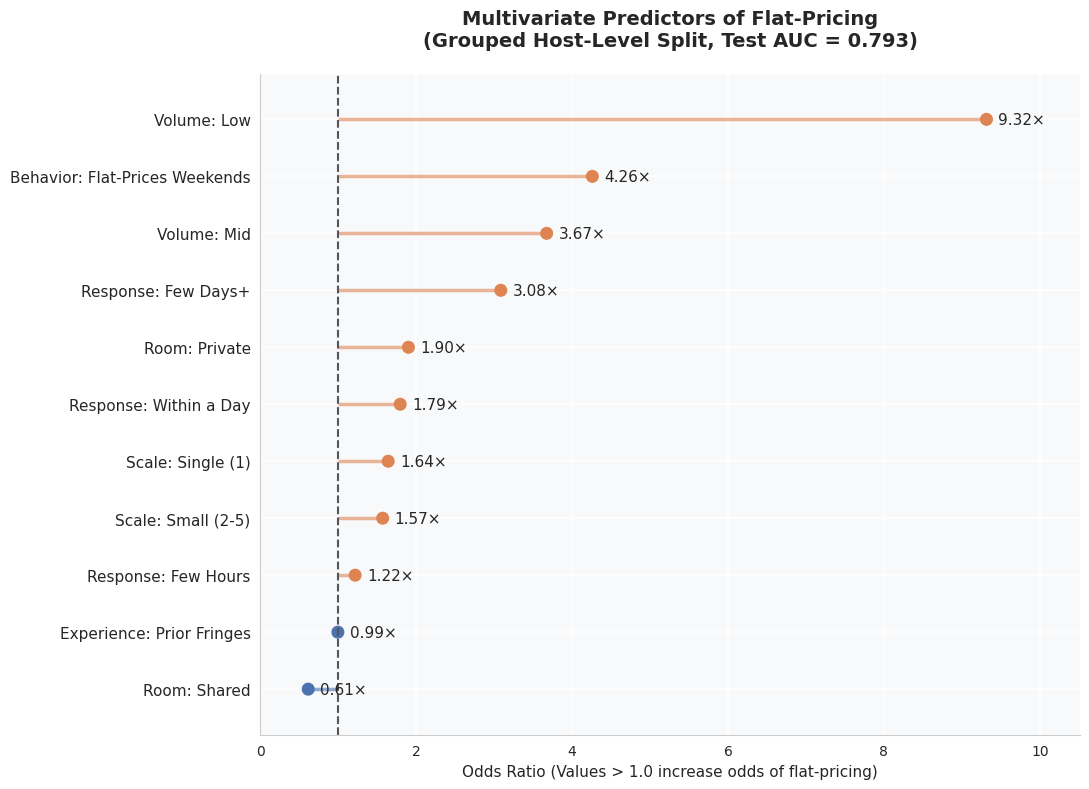

In [ ]:
# ── 10. MULTIVARIATE MODEL ────────────────────────────────────

from sklearn.model_selection import GroupShuffleSplit

# Start with the dataset containing prior experience
model_data = fringe_experience.copy()

# Add weekend pricing behaviour
model_data = model_data.merge(
    weekend_price_calc[['is_weekend_flat']],
    on='listing_id',
    how='left'
)

# Add host_id for grouped train/test splitting
model_data['host_id'] = model_data['listing_id'].map(
    listings.set_index('id')['host_id']
)

# Remove observations with missing model inputs
model_data = model_data.dropna(
    subset=[
        'host_tier',
        'booking_volume_tier',
        'host_response_time',
        'room_type',
        'is_weekend_flat',
        'prior_fringes',
        'is_flat_pricer',
        'host_id'
    ]
).copy()

# Fastest response time as the reference category
model_data['host_response_time'] = pd.Categorical(
    model_data['host_response_time'],
    categories=[
        'within_an_hour',
        'within_a_few_hours',
        'within_a_day',
        'a_few_days_or_more'
    ],
    ordered=True
)

# Encode categorical variables
features = pd.get_dummies(
    model_data[[
        'host_tier',
        'booking_volume_tier',
        'host_response_time',
        'room_type',
        'is_weekend_flat',
        'prior_fringes'
    ]],
    drop_first=True
)

X = features.values
y = model_data['is_flat_pricer'].astype(int).values
groups = model_data['host_id'].values

# Grouped host-level split
gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    gss.split(X, y, groups=groups)
)

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

# Fit model
clf = LogisticRegression(max_iter=1000, random_state=42)
clf.fit(X_train, y_train)

# Model performance
train_auc = roc_auc_score(
    y_train,
    clf.predict_proba(X_train)[:, 1]
)

test_auc = roc_auc_score(
    y_test,
    clf.predict_proba(X_test)[:, 1]
)

print("Model Performance (Grouped Host-Level Split):")
print(f"  Train AUC: {train_auc:.3f}")
print(f"  Test AUC : {test_auc:.3f}\n")

# Odds ratios
coef_df = pd.DataFrame({
    'feature': features.columns,
    'odds_ratio': np.exp(clf.coef_[0])
}).sort_values('odds_ratio').reset_index(drop=True)

# Clean feature labels
clean_labels = (
    coef_df['feature']
    .str.replace('booking_volume_tier_mid_volume', 'Volume: Mid')
    .str.replace('booking_volume_tier_low_volume', 'Volume: Low')
    .str.replace('host_tier_small_portfolio', 'Scale: Small (2-5)')
    .str.replace('host_tier_single_property', 'Scale: Single (1)')
    .str.replace('host_response_time_within_a_few_hours', 'Response: Few Hours')
    .str.replace('host_response_time_within_a_day', 'Response: Within a Day')
    .str.replace('host_response_time_a_few_days_or_more', 'Response: Few Days+')
    .str.replace('room_type_Private room', 'Room: Private')
    .str.replace('room_type_Shared room', 'Room: Shared')
    .str.replace('is_weekend_flat_True', 'Behavior: Flat-Prices Weekends')
    .str.replace('prior_fringes', 'Experience: Prior Fringes')
)

colors = [
    ACCENT if v > 1.0 else PRIMARY
    for v in coef_df['odds_ratio']
]

fig, ax = plt.subplots(figsize=(11, 8))
y_pos = range(len(coef_df))

ax.hlines(
    y_pos,
    1,
    coef_df['odds_ratio'],
    color=colors,
    linewidth=2.5,
    alpha=0.6
)

ax.scatter(
    coef_df['odds_ratio'],
    y_pos,
    color=colors,
    s=70
)

ax.axvline(
    1.0,
    color='#555',
    linestyle='--',
    linewidth=1.5
)

# Odds ratio labels
for i, row in coef_df.iterrows():
    ax.text(
        row['odds_ratio'] + 0.15,
        i,
        f"{row['odds_ratio']:.2f}×",
        va='center',
        fontsize=11
    )

ax.set_yticks(y_pos)
ax.set_yticklabels(clean_labels, fontsize=11)

ax.set_xlabel(
    'Odds Ratio (Values > 1.0 increase odds of flat-pricing)',
    fontsize=11
)

ax.set_title(
    f'Multivariate Predictors of Flat-Pricing\n'
    f'(Grouped Host-Level Split, Test AUC = {test_auc:.3f})',
    fontweight='bold',
    fontsize=14,
    pad=20
)

ax.set_xlim(0, coef_df['odds_ratio'].max() + 1.2)
ax.margins(y=0.08)

plt.tight_layout()
plt.show()

**Key Takeaway:** After accounting for multiple host and listing characteristics, booking volume remains the strongest factor associated with flat-pricing. Low-volume hosts have **9.32×** higher odds of flat-pricing than high-volume hosts, while weekend flat-pricers have **4.26×** higher odds.

By comparison, prior Fringe experience shows little relationship with flat-pricing (**0.99×**), consistent with the earlier descriptive analysis.

## 11. Flat-Pricer Segmentation

The previous analysis showed that booking volume, response time, and weekend pricing behaviour are associated with flat-pricing. To better understand the composition of flat-pricers, listings are grouped using these characteristics.

Three segments are examined:

1. **Low Volume / Low Activity:** Hosts in the lowest booking volume tier.
2. **High Volume / Slow Response:** Hosts with mid- or high-volume activity and response times greater than 24 hours.
3. **High Volume / Fast Response:** Hosts with mid- or high-volume activity and response times within 24 hours.

In [ ]:
# ── 11. FLAT-PRICER SEGMENTATION ──────────────────────────────

flat_pricers = fringe_listings[
    fringe_listings['is_flat_pricer']
].copy()

def segment_flat_pricer(row):
    if row['booking_volume_tier'] == 'low_volume':
        return 'Low Volume / Low Activity'
    elif row['host_response_time'] in [
        'within_a_day',
        'a_few_days_or_more'
    ]:
        return 'High Volume / Slow Response'
    else:
        return 'High Volume / Fast Response'

# Assign segment labels
flat_pricers['host_segment'] = flat_pricers.apply(
    segment_flat_pricer,
    axis=1
)

print("=== FLAT-PRICER COMPOSITION ===\n")

segment_counts = flat_pricers['host_segment'].value_counts()

for segment, count in segment_counts.items():
    print(
        f"{segment:30s} : "
        f"{count:,} listings "
        f"({count/len(flat_pricers)*100:.1f}%)"
    )

=== FLAT-PRICER COMPOSITION ===

High Volume / Fast Response    : 812 listings (56.9%)
Low Volume / Low Activity      : 483 listings (33.8%)
High Volume / Slow Response    : 133 listings (9.3%)


## 12. Revenue Opportunity Estimate

The final step is to estimate the potential revenue difference associated with flat-pricing during the Fringe.

For each flat-pricer, a benchmark price is constructed using the median Fringe markup of comparable listings within the same neighbourhood and room type. The gap between the listing's actual Fringe price and this peer-group benchmark is then translated into an estimated revenue opportunity using a conservative occupancy assumption.

This estimate is intended to illustrate the potential scale of the pricing gap rather than predict realized revenue.

In [ ]:
# ── REVENUE OPPORTUNITY ───────────────────────────────────────

# Peer-group median markup (neighbourhood × room type)
peer_group_markups = (
    fringe_listings
    .groupby(
        ['neighbourhood_cleansed', 'room_type'],
        observed=True
    )['median_fringe_price_index']
    .median()
    .rename('peer_median_markup')
    .reset_index()
)

# Flat-pricers with peer-group benchmarks
flat_pricers = fringe_listings[
    fringe_listings['is_flat_pricer']
].copy()

flat_pricers = (
    flat_pricers
    .reset_index()
    .merge(
        peer_group_markups,
        on=['neighbourhood_cleansed', 'room_type'],
        how='left'
    )
    .set_index('listing_id')
)

# Fallback for sparse peer groups
GLOBAL_MEDIAN_MARKUP = 1.77

flat_pricers['peer_median_markup'] = (
    flat_pricers['peer_median_markup']
    .fillna(GLOBAL_MEDIAN_MARKUP)
)

# Current vs peer-group pricing
flat_pricers['current_median_price'] = (
    flat_pricers['baseline_median_price'] *
    flat_pricers['median_fringe_price_index']
)

flat_pricers['target_market_price'] = (
    flat_pricers['baseline_median_price'] *
    flat_pricers['peer_median_markup']
)

# Daily revenue difference
flat_pricers['daily_revenue_gap'] = (
    flat_pricers['target_market_price'] -
    flat_pricers['current_median_price']
).clip(lower=0)

# Estimated revenue opportunity
ASSUMED_OCCUPANCY = 0.60
FRINGE_DAYS = 25

flat_pricers['total_missed_revenue'] = (
    flat_pricers['daily_revenue_gap'] *
    ASSUMED_OCCUPANCY *
    FRINGE_DAYS
)

total_host_missed = flat_pricers['total_missed_revenue'].sum()

# Airbnb commission estimate
AIRBNB_HOST_FEE = 0.03
AIRBNB_GUEST_FEE = 0.15
TOTAL_TAKE_RATE = AIRBNB_HOST_FEE + AIRBNB_GUEST_FEE

airbnb_missed = total_host_missed * TOTAL_TAKE_RATE

# Results
print("=== REVENUE OPPORTUNITY ESTIMATE ===\n")

print(
    f"Assumed Occupancy : "
    f"{ASSUMED_OCCUPANCY*100:.0f}%"
)

print(
    f"Festival Window   : "
    f"{FRINGE_DAYS} days"
)

print(
    f"Airbnb Take Rate  : "
    f"{TOTAL_TAKE_RATE*100:.0f}% "
    f"(3% host + 15% guest)\n"
)

print(f"Flat-Pricers Identified      : {len(flat_pricers):,}")
print(f"Estimated Host Revenue Gap   : £{total_host_missed:,.0f}")
print(f"Estimated Airbnb Commission  : £{airbnb_missed:,.0f}\n")

# Breakdown by room type
print("=== BREAKDOWN BY ROOM TYPE ===")

breakdown = (
    flat_pricers
    .groupby('room_type')
    .agg(
        listings=('total_missed_revenue', 'count'),
        total_missed=('total_missed_revenue', 'sum'),
        avg_per_listing=('total_missed_revenue', 'mean'),
        median_gap_per_night=('daily_revenue_gap', 'median')
    )
    .sort_values('total_missed', ascending=False)
)

breakdown_display = breakdown.copy()

breakdown_display['total_missed'] = (
    breakdown['total_missed']
    .map('£{:,.0f}'.format)
)

breakdown_display['avg_per_listing'] = (
    breakdown['avg_per_listing']
    .map('£{:,.0f}'.format)
)

breakdown_display['median_gap_per_night'] = (
    breakdown['median_gap_per_night']
    .map('£{:,.2f}'.format)
)

print(breakdown_display)

# Listings with no estimated revenue gap
excluded = (flat_pricers['daily_revenue_gap'] == 0).sum()

print(
    f"\nNote: {excluded} listings excluded "
    f"(peer-group median markup was below or equal to their actual markup)"
)

=== REVENUE OPPORTUNITY ESTIMATE ===

Assumed Occupancy : 60%
Festival Window   : 25 days
Airbnb Take Rate  : 18% (3% host + 15% guest)

Flat-Pricers Identified      : 1,428
Estimated Host Revenue Gap   : £1,772,556
Estimated Airbnb Commission  : £319,060

=== BREAKDOWN BY ROOM TYPE ===
                 listings total_missed avg_per_listing median_gap_per_night
room_type                                                                  
Entire home/apt       721   £1,575,055          £2,185               £95.45
Private room          702     £196,794            £280                £7.55
Shared room             5         £707            £141                £0.00

Note: 230 listings excluded (peer-group median markup was below or equal to their actual markup)


## Conclusion

This analysis examined how Airbnb hosts responded to the demand surge created by the 2019 Edinburgh Fringe Festival.

Three findings stand out:

1. The Fringe generated a substantial market-wide pricing response, with median listing prices reaching approximately **1.78×** their typical off-season levels.

2. Host behaviour appeared to be more strongly associated with Fringe pricing decisions than host tenure or portfolio size. In particular, booking activity and routine weekend pricing behaviour showed the strongest relationships with flat-pricing.

3. Under the assumptions used in this analysis, flat-pricing was associated with a meaningful estimated revenue opportunity when compared with similar listings in the same neighbourhood and room type.

Together, these results suggest that routine pricing behaviour may provide a more useful signal of festival pricing response than experience or host scale alone.